# Part II: Embedding Variants and Ablation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
import time
import math
import re

import gensim
from gensim.models import Word2Vec
import torchtext.vocab as torchtext_vocab

c:\Users\jenni\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("stanfordnlp/imdb")
train_lines = dataset["train"]["text"]

In [3]:
def tokenize(line):
    line = line.strip().lower()
    if not line:
        return []
    # Skip Wikipedia section headers like "== History =="
    if re.fullmatch(r"=+\s*.*\s*=+", line):
        return []
    # Extract words and punctuation as tokens
    return re.findall(r"\w+|[^\w\s]", line)

In [4]:
MAX_LINES = 300  # limit for speed (increase if you want a stronger model)

tokens = []
start_train1 = time.time()
for line in train_lines[:MAX_LINES]:
    toks = tokenize(line)
    if toks:
        tokens.extend(["<s>"] + toks + ["</s>"])

print("Total tokens:", len(tokens))

# Vocabulary = set of all unique tokens we observed
vocab = set(tokens)
print("Vocab size:", len(vocab))
end_train1 = time.time()

Total tokens: 86214
Vocab size: 8199


In [5]:
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

In [6]:
class LSTM_with_Embeddings(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, 
                 embedding_type='trainable', pretrained_embeddings=None):
        super().__init__()
        
        self.embedding_type = embedding_type
        self.embed_size = embed_size
        self.vocab_size = vocab_size
        
        # Initialize embedding layer based on type
        if embedding_type == 'trainable':
            # Trainable embeddings from scratch
            self.embedding = nn.Embedding(vocab_size, embed_size)
            
        elif embedding_type == 'fixed_scratch':
            # Fixed embeddings trained from scratch (will be frozen)
            self.embedding = nn.Embedding(vocab_size, embed_size)
            self.embedding.weight.requires_grad = False
            
        elif embedding_type == 'pretrained':
            # Fixed pretrained embeddings
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings, 
                freeze=True  # Freeze the embeddings
            )
        
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, hidden):
        x = self.embedding(x)
        output, hidden = self.lstm(x, hidden)
        output = self.fc(output)
        return output, hidden

In [7]:
# word2vec embeddings
def word2vec_embeddings(tokenized_sentences, embed_size=128):

    # Prepare sentences for Word2Vec (split into sentences)
    sentences = []
    current_sentence = []
    
    for token in tokenized_sentences:
        current_sentence.append(token)
        if token == '</s>':
            if len(current_sentence) > 1:  # Skip empty sentences
                sentences.append(current_sentence)
            current_sentence = []
    
    # Train model
    w2v_model = Word2Vec(sentences=sentences, 
                         vector_size=embed_size,
                         window=5,
                         min_count=1,
                         workers=4,
                         epochs=10)
    
    return w2v_model

def create_embedding_matrix_from_word2vec(w2v_model, word_to_idx, embed_size):

    embedding_matrix = np.zeros((len(word_to_idx), embed_size))
    
    for word, idx in word_to_idx.items():
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
        else:
            # Random initialization for OOV words
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embed_size,))
    
    return torch.FloatTensor(embedding_matrix)

In [8]:
#pretrained GloVe embeddings
def get_pretrained_glove_embeddings(word_to_idx, embed_size=128):

    if embed_size == 50:
        glove = torchtext_vocab.GloVe(name='6B', dim=50)
    elif embed_size == 100:
        glove = torchtext_vocab.GloVe(name='6B', dim=100)
    elif embed_size == 200:
        glove = torchtext_vocab.GloVe(name='6B', dim=200)
    else:
        glove = torchtext_vocab.GloVe(name='6B', dim=300)  # Default to 300
    
    embedding_matrix = np.zeros((len(word_to_idx), embed_size))
    
    for word, idx in word_to_idx.items():
        if word in glove.stoi:
            embedding_matrix[idx] = glove.vectors[glove.stoi[word]].numpy()
        else:
            # Random initialization for OOV words
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embed_size,))
    
    return torch.FloatTensor(embedding_matrix)

In [9]:
def train_embedding_variant(model, data_loader, vocab_size, num_epochs=5, variant_name=""):

    global learning_rate, num_layers, hidden_size
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    print(f"\n{'='*50}")
    print(f"Training {variant_name}")
    print(f"{'='*50}")
    
    history = {
        'epoch_losses': [],
        'perplexities': [],
        'training_time': 0
    }
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        total_loss = 0
        progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for x_batch, y_batch in progress_bar:
            hidden = (torch.zeros(num_layers, x_batch.size(0), hidden_size),
                     torch.zeros(num_layers, x_batch.size(0), hidden_size))
            
            optimizer.zero_grad()
            output, hidden = model(x_batch, hidden)
            loss = criterion(output.view(-1, vocab_size), y_batch.view(-1))
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        avg_loss = total_loss / len(data_loader)
        perplexity = math.exp(avg_loss)
        
        history['epoch_losses'].append(avg_loss)
        history['perplexities'].append(perplexity)

        print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f}, Perplexity: {perplexity:.4f}")
    
    history['training_time'] = time.time() - start_time
    return model, history

In [10]:
class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx:idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.data[idx + 1:idx + self.seq_len + 1], dtype=torch.long)
        return x, y

In [11]:
import torch.nn.functional as F

# Generate text
def generate_text(model, start_text, max_len=20):
    model.eval()
    # Convert starting text to indices and create input tensor
    input_ids = torch.tensor([word_to_idx[word] for word in start_text],
                             dtype=torch.long).unsqueeze(0) # Shape: (1, len(start_text))
    generated_text = list(start_text) # Store the generated words
    hidden = None # Initialize hidden state
    
    for _ in range(max_len):
        output, hidden = model(input_ids, hidden) # Forward pass
        next_word_id = output[:, -1, :].argmax(dim=-1).item() # Take the last step's output
        next_word = idx_to_word[next_word_id] # Convert to word
        generated_text.append(next_word)
        input_ids = torch.tensor([[next_word_id]], dtype=torch.long) # Update input with the predicted word
        if next_word == ".": # Stop generating at a full stop
            break
    return ' '.join(generated_text)

In [12]:
vocab_size = len(vocab)
seq_len = 100
batch_size = 32
embed_size = 100
hidden_size = 256
num_layers = 2
learning_rate = 0.001
num_epochs = 5

In [13]:
# train word2vec embeddings on the dataset
w2v_model = word2vec_embeddings(tokens, embed_size)
w2v_embeddings = create_embedding_matrix_from_word2vec(w2v_model, word_to_idx, embed_size)

In [14]:
# get pretrained GloVe embeddings
glove_embeddings = get_pretrained_glove_embeddings(word_to_idx, embed_size = 100)

In [15]:
# Create dataset and dataloader
encoded_text = [word_to_idx[word] for word in tokens]
data = torch.tensor(encoded_text, dtype=torch.long)
data = data.view(-1)
dataset = TextDataset(data, seq_len)
data_loader = DataLoader(dataset, batch_size = batch_size, shuffle = True)

In [16]:
embedding_variants = [
    {
        'name': 'Variant A: Trainable Embeddings (Learned from Scratch)',
        'type': 'trainable',
        'embeddings': None,
        'description': 'Randomly initialized embeddings that are updated during training'
    },
    {
        'name': 'Variant B: Fixed Word2Vec Embeddings (Trained on Data)',
        'type': 'pretrained',  # Using pretrained but freezing them
        'embeddings': w2v_embeddings,
        'description': 'Word2Vec embeddings trained on dataset, then frozen'
    },
    {
        'name': 'Variant C: Fixed Pretrained GloVe Embeddings (Public)',
        'type': 'pretrained',
        'embeddings': glove_embeddings,
        'description': 'Public GloVe embeddings (trained on general corpus), frozen'
    }
]

In [17]:
results = {}
trained_models = {}

for variant in embedding_variants:
    print(f"Training {variant['name']}")
    print(f"Description: {variant['description']}")
    
    # Initialize model
    model = LSTM_with_Embeddings(
        vocab_size=vocab_size,
        embed_size=embed_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        embedding_type=variant['type'],
        pretrained_embeddings=variant['embeddings']
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Train model
    trained_model, history = train_embedding_variant(
        model, 
        data_loader, 
        vocab_size,
        num_epochs=num_epochs,
        variant_name=variant['name']
    )

    results[variant['name']] = {
        'history': history,
        # We'll add sample text later
    }
    
    trained_models[variant['name']] = trained_model

Training Variant A: Trainable Embeddings (Learned from Scratch)
Description: Randomly initialized embeddings that are updated during training
Total parameters: 3,819,971
Trainable parameters: 3,819,971

Training Variant A: Trainable Embeddings (Learned from Scratch)


Epoch 1/5:   0%|          | 0/2692 [00:00<?, ?it/s]C:\Users\jenni\AppData\Local\Temp\ipykernel_30072\2358578543.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(self.data[idx:idx + self.seq_len], dtype=torch.long)
C:\Users\jenni\AppData\Local\Temp\ipykernel_30072\2358578543.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.data[idx + 1:idx + self.seq_len + 1], dtype=torch.long)
Epoch 1/5: 100%|██████████| 2692/2692 [08:44<00:00,  5.13it/s, loss=3.47]


Epoch 1/5, Avg Loss: 4.6135, Perplexity: 100.8367


Epoch 2/5: 100%|██████████| 2692/2692 [10:00<00:00,  4.48it/s, loss=1.73]


Epoch 2/5, Avg Loss: 2.3655, Perplexity: 10.6493


...

Epoch 3/5, Avg Loss: 2.1190, Perplexity: 8.3225


Epoch 4/5: 100%|██████████| 2692/2692 [09:39<00:00,  4.64it/s, loss=0.997]


Epoch 4/5, Avg Loss: 1.2229, Perplexity: 3.3969


Epoch 5/5: 100%|██████████| 2692/2692 [09:39<00:00,  4.64it/s, loss=0.387]

Epoch 5/5, Avg Loss: 0.6472, Perplexity: 1.9101


In [ ]:
for variant_name, model in trained_models.items():
    print(f"\nGenerating text for: {variant_name}")
    sample_text = generate_text(model, ['this', 'movie'])
    print(f"Generated: {sample_text}")
    
    # Add sample text to results
    results[variant_name]['sample_text'] = sample_text

# Now you can see all results
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

for variant_name, result in results.items():
    print(f"\n{variant_name}")
    print(f"  Final Loss: {result['history']['epoch_losses'][-1]:.4f}")
    print(f"  Final Perplexity: {result['history']['perplexities'][-1]:.2f}")
    print(f"  Sample: {result['sample_text']}")


Generating text for: Variant A: Trainable Embeddings (Learned from Scratch)
Generated: this movie is that it has a few absolutely brilliant moments that keep you hoping that there are more to come .

Generating text for: Variant B: Fixed Word2Vec Embeddings (Trained on Data)
Generated: this movie .

Generating text for: Variant C: Fixed Pretrained GloVe Embeddings (Public)
Generated: this movie .

FINAL RESULTS SUMMARY

Variant A: Trainable Embeddings (Learned from Scratch)
  Final Loss: 0.1843
  Final Perplexity: 1.20
  Sample: this movie is that it has a few absolutely brilliant moments that keep you hoping that there are more to come .

Variant B: Fixed Word2Vec Embeddings (Trained on Data)
  Final Loss: 2.0263
  Final Perplexity: 7.59
  Sample: this movie .

Variant C: Fixed Pretrained GloVe Embeddings (Public)
  Final Loss: 0.6472
  Final Perplexity: 1.91
  Sample: this movie .


In [22]:
comparison_data = []
for variant_name, result in results.items():
    history = result['history']
    comparison_data.append({
        'Variant': variant_name[:30] + '...' if len(variant_name) > 30 else variant_name,
        'Final Loss': f"{history['epoch_losses'][-1]:.4f}",
        'Final PPL': f"{history['perplexities'][-1]:.2f}",
        'Training Time (s)': f"{history['training_time']:.1f}",
        'Loss Reduction': f"{history['epoch_losses'][0] - history['epoch_losses'][-1]:.2f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                          Variant Final Loss Final PPL Training Time (s) Loss Reduction
Variant A: Trainable Embedding...     0.1843      1.20            2906.2           4.43
Variant B: Fixed Word2Vec Embe...     2.0263      7.59            2900.6           3.34
Variant C: Fixed Pretrained Gl...     0.6472      1.91            2895.4           4.57


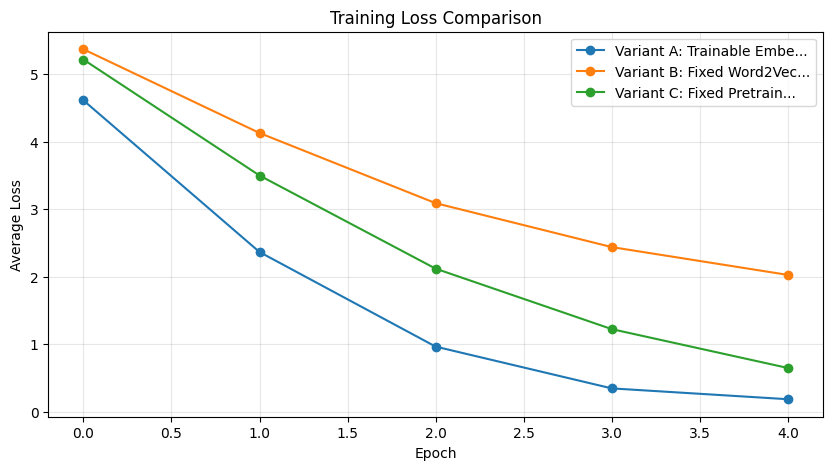

In [23]:
import matplotlib.pyplot as plt

# Plot training curves
plt.figure(figsize=(10, 5))

# Loss curves
for variant_name, result in results.items():
    plt.plot(result['history']['epoch_losses'], marker='o', label=variant_name[:25] + '...')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

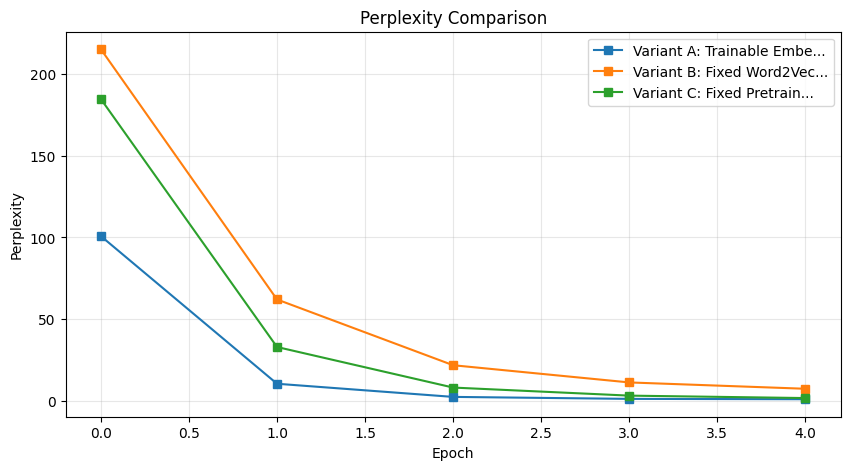

In [24]:
# Perplexity curves
plt.figure(figsize= (10,5))
for variant_name, result in results.items():
    plt.plot(result['history']['perplexities'], marker='s', label=variant_name[:25] + '...')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Perplexity Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

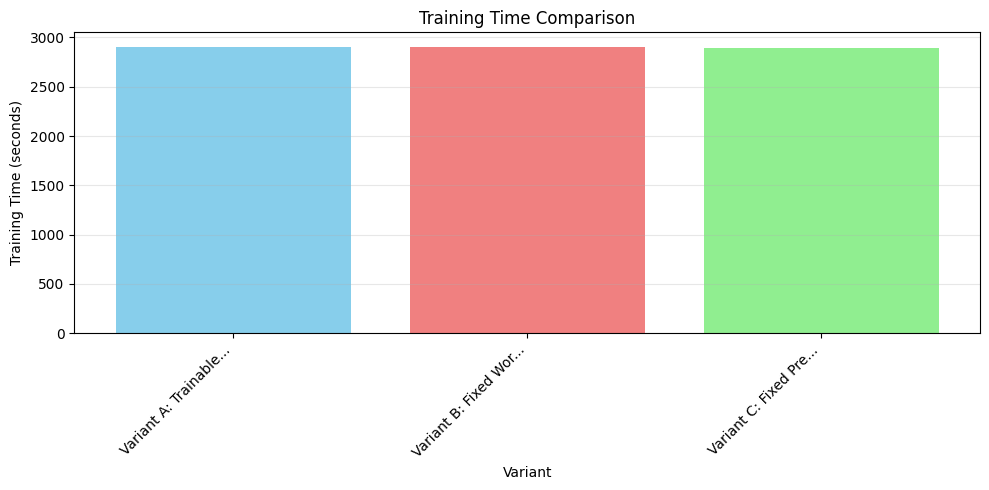

In [25]:
# Training time comparison
plt.figure(figsize= (10,5))
variants = [v[:20] + '...' for v in results.keys()]
times = [result['history']['training_time'] for result in results.values()]
colors = ['skyblue', 'lightcoral', 'lightgreen']
plt.bar(range(len(variants)), times, color=colors)
plt.xlabel('Variant')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.xticks(range(len(variants)), variants, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Summary analysis

# Find best performer by final perplexity
best_variant = min(results.keys(), key=lambda x: results[x]['history']['perplexities'][-1])
worst_variant = max(results.keys(), key=lambda x: results[x]['history']['perplexities'][-1])

print(f"\n1. Best performing variant:")
print(f"   {best_variant}")
print(f"   Final Perplexity: {results[best_variant]['history']['perplexities'][-1]:.2f}")

print(f"\n2. Worst performing variant:")
print(f"   {worst_variant}")
print(f"   Final Perplexity: {results[worst_variant]['history']['perplexities'][-1]:.2f}")

print(f"\n3. Training speed comparison:")
fastest = min(results.keys(), key=lambda x: results[x]['history']['training_time'])
slowest = max(results.keys(), key=lambda x: results[x]['history']['training_time'])
print(f"   Fastest: {fastest} ({results[fastest]['history']['training_time']:.1f}s)")
print(f"   Slowest: {slowest} ({results[slowest]['history']['training_time']:.1f}s)")

print(f"\n4. Convergence analysis (loss reduction from epoch 1 to {num_epochs}):")
for variant_name, result in results.items():
    loss_reduction = result['history']['epoch_losses'][0] - result['history']['epoch_losses'][-1]
    print(f"   {variant_name[:30]}: {loss_reduction:.2f} reduction")


1. Best performing variant:
   Variant A: Trainable Embeddings (Learned from Scratch)
   Final Perplexity: 1.20

2. Worst performing variant:
   Variant B: Fixed Word2Vec Embeddings (Trained on Data)
   Final Perplexity: 7.59

3. Training speed comparison:
   Fastest: Variant C: Fixed Pretrained GloVe Embeddings (Public) (2895.4s)
   Slowest: Variant A: Trainable Embeddings (Learned from Scratch) (2906.2s)

4. Convergence analysis (loss reduction from epoch 1 to 5):
   Variant A: Trainable Embedding: 4.43 reduction
   Variant B: Fixed Word2Vec Embe: 3.34 reduction
   Variant C: Fixed Pretrained Gl: 4.57 reduction
